In [4]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [5]:
N = 10
saturation = 16383
noise_rms = 20
dark = 150

sigma_x = 1
sigma_y = 2
theta = 30 * np.pi / 180

def gauss2D(x, y, x0, y0, sigma_x, sigma_y, A, theta=0):
    """Returns a 2D Gaussian function evaluated at (x, y) with center (x0, y0), standard deviations sigma_x and sigma_y, and amplitude A."""
    return A * np.exp(-(((x - x0) * np.cos(theta) + (y - y0) * np.sin(theta))**2 / (2 * sigma_x**2) + ((-(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta))**2 / (2 * sigma_y**2))))

def flux_to_amp(flux, sigma_x, sigma_y):
    """Converts a total flux to an amplitude for a 2D Gaussian with given standard deviations."""
    return flux / (2 * np.pi * sigma_x * sigma_y)

def output(flux):
    img = dark + np.random.normal(0, noise_rms, (N, N)) + gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2, N//2, sigma_x, sigma_y, flux_to_amp(flux, sigma_x, sigma_y), theta)
    img = np.clip(img, 0, saturation)
    return img - dark

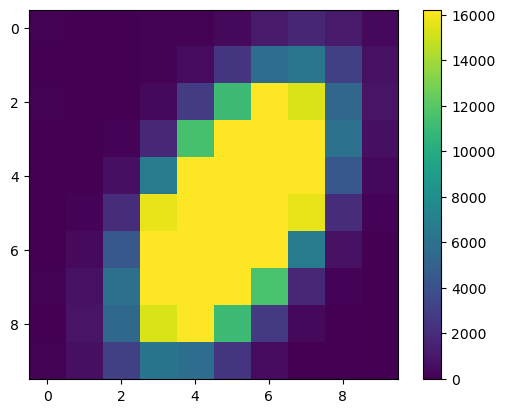

In [6]:
im = plt.imshow(output(1000000))
plt.colorbar(im)
plt.show()

In [7]:
f"{np.sum(output(0)) / np.sum(output(1000000)):.2e}"

'2.89e-04'

In [8]:
def model(flux, x0, y0, sigma_x, sigma_y, theta=0):
    img = dark + gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2 + x0, N//2 + y0, sigma_x, sigma_y, flux_to_amp(flux, sigma_x, sigma_y), theta)
    img = np.clip(img, 0, saturation)
    return img - dark

In [9]:
# Fit model

data = output(1000000)
popt, pcov = curve_fit(lambda f, flux, x0, y0, sigma_x, sigma_y, theta: model(flux, x0, y0, sigma_x, sigma_y, theta).flatten(), np.zeros(data.size), data.flatten(), p0=[1000000, 0, 0, sigma_x, sigma_y, 0], bounds=(0, 1e7))
popt

array([9.98882361e+05, 6.76430954e-14, 2.61420178e-05, 1.00079733e+00,
       2.00112957e+00, 5.23873730e-01])

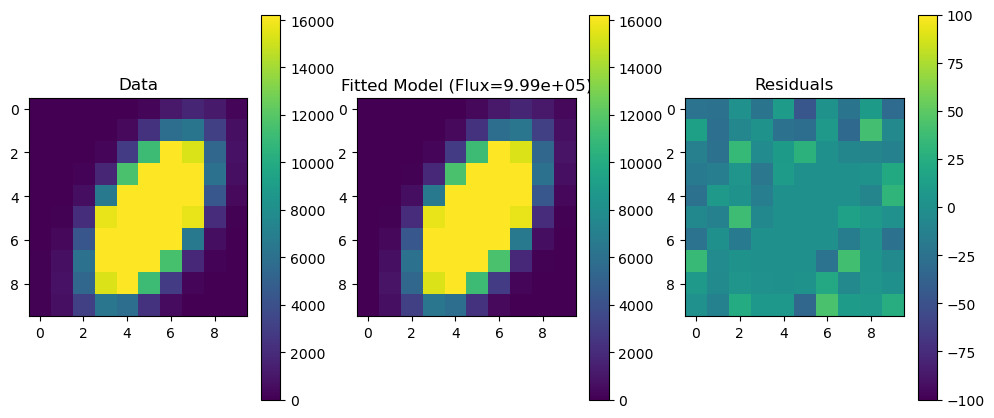

In [10]:
# Plot fit

fitted_flux = popt[0]
fitted_img = model(*popt)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Data")
plt.imshow(data, vmin=0, vmax=saturation - dark)
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title(f"Fitted Model (Flux={fitted_flux:.2e})")
plt.imshow(fitted_img, vmin=0, vmax=saturation - dark)
plt.colorbar()
plt.subplot(1, 3, 3)
plt.title("Residuals")
plt.imshow(data - fitted_img, vmin=-100, vmax=100)
plt.colorbar()
plt.show()


---

# Pratique

In [11]:
import phobos
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

[1.64666631e+05 1.57122138e-38 2.71103010e-01 2.41892963e+00
 1.27853027e+00 3.07540309e-02]


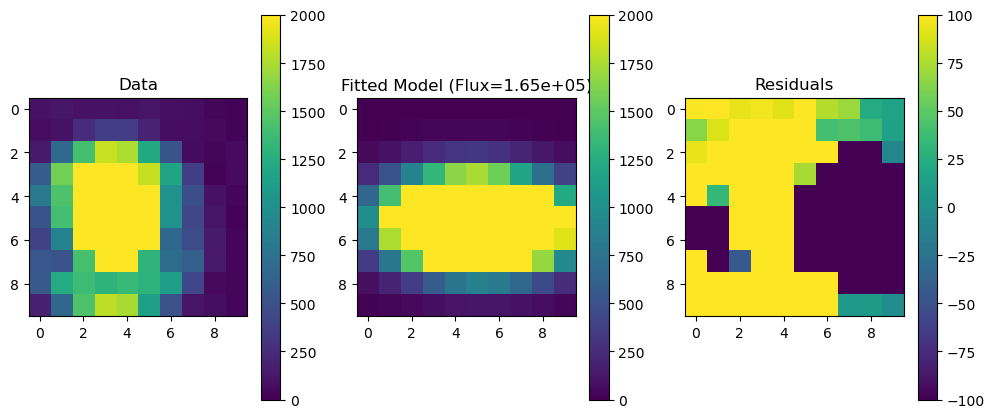

In [31]:
N = phobos.Config().get('cred3.output_sizes')
saturation = 16383
dark_img = phobos.Cred3().dark_shm_obj.get_latest_data() # Dark image
dark = phobos.Cred3().crop_outputs_from_image(dark_img)[0]

output_img = phobos.Cred3().get_image()
output = phobos.Cred3().crop_outputs_from_image(output_img)[0]

def model2(flux, x0, y0, sigma_x, sigma_y, theta=0):
    img = gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2 + x0, N//2 + y0, sigma_x, sigma_y, flux_to_amp(flux, sigma_x, sigma_y), theta)
    saturation_per_pixel = saturation - dark
    img = np.clip(img, -np.inf, saturation_per_pixel)
    return img

guess_flux = np.sum(output)
guess_sigmax = N/10
guess_sigmay = N/10
guess_theta = 0
guess_x0 = 0
guess_y0 = 0

popt, pcov = curve_fit(
    lambda f, flux, x0, y0, sigma_x, sigma_y, theta: model2(flux, x0, y0, sigma_x, sigma_y, theta).flatten(),
    np.zeros(output.size), output.flatten(), p0=[guess_flux, guess_x0, guess_y0, guess_sigmax, guess_sigmay, guess_theta], bounds=(0, 1e7))

print(popt)

fitted_flux = popt[0]
fitted_img = model2(*popt)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Data")
plt.imshow(output, vmin=0, vmax=np.max(dark))
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title(f"Fitted Model (Flux={fitted_flux:.2e})")
plt.imshow(fitted_img, vmin=0, vmax=np.max(dark))
plt.colorbar()
plt.subplot(1, 3, 3)
plt.title("Residuals")
plt.imshow(output - fitted_img, vmin=-100, vmax=100)
plt.colorbar()
plt.show()


[9.49936615e+04 3.86467107e-38 2.53469232e-01 2.25276084e+00
 8.95541918e-01 7.41263209e-35 6.60953538e+05 1.16423246e-38
 1.55221698e+01 1.52157854e+01 9.94380578e-01 1.45166388e+00]


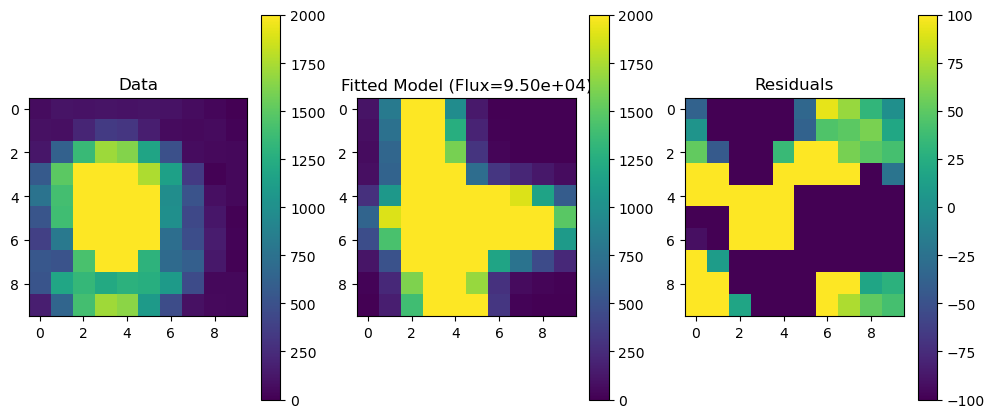

In [32]:
N = phobos.Config().get('cred3.output_sizes')
saturation = 16383
dark_img = phobos.Cred3().dark_shm_obj.get_latest_data() # Dark image
dark = phobos.Cred3().crop_outputs_from_image(dark_img)[0]

output_img = phobos.Cred3().get_image()
output = phobos.Cred3().crop_outputs_from_image(output_img)[0]

def model3(fluxa, x0a, y0a, sigma_xa, sigma_ya, thetaa, fluxb, x0b, y0b, sigma_xb, sigma_yb, thetab):
    img_a = gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2 + x0a, N//2 + y0a, sigma_xa, sigma_ya, flux_to_amp(fluxa, sigma_xa, sigma_ya), thetaa)
    img_b = gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2 + x0b, N//2 + y0b, sigma_xb, sigma_yb, flux_to_amp(fluxb, sigma_xb, sigma_yb), thetab)
    img = img_a + img_b
    saturation_per_pixel = saturation - dark
    img = np.clip(img, -np.inf, saturation_per_pixel)
    return img

guess_flux = np.sum(output)
guess_sigmax = N/10
guess_sigmay = N/10
guess_theta = 0
guess_x0 = 0
guess_y0 = 0

popt, pcov = curve_fit(
    lambda f, fluxa, x0a, y0a, sigma_xa, sigma_ya, thetaa, fluxb, x0b, y0b, sigma_xb, sigma_yb, thetab: model3(fluxa, x0a, y0a, sigma_xa, sigma_ya, thetaa, fluxb, x0b, y0b, sigma_xb, sigma_yb, thetab).flatten(),
    np.zeros(output.size), output.flatten(), p0=[guess_flux, guess_x0, guess_y0, guess_sigmax, guess_sigmay, guess_theta, guess_flux, guess_x0, guess_y0+1, guess_sigmax, guess_sigmay, guess_theta], bounds=(0, 1e7))

print(popt)

fitted_flux = popt[0]
fitted_img = model3(*popt)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Data")
plt.imshow(output, vmin=0, vmax=np.max(dark))
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title(f"Fitted Model (Flux={fitted_flux:.2e})")
plt.imshow(fitted_img, vmin=0, vmax=np.max(dark))
plt.colorbar()
plt.subplot(1, 3, 3)
plt.title("Residuals")
plt.imshow(output - fitted_img, vmin=-100, vmax=100)
plt.colorbar()
plt.show()

